In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")  

In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.shape

(891, 12)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Did gender affect survival?

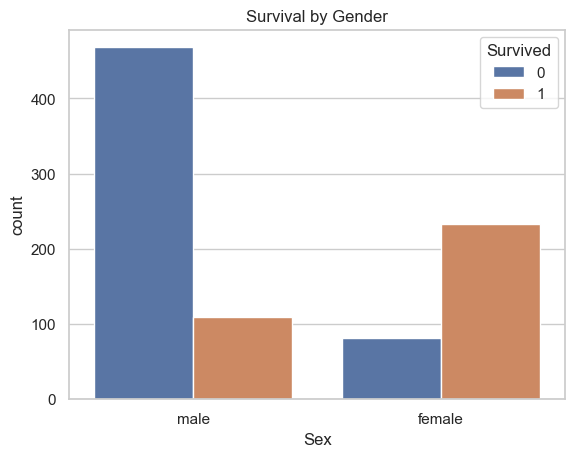

In [10]:
sns.countplot(
    data=train,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.show()

Analyze survival by passenger class

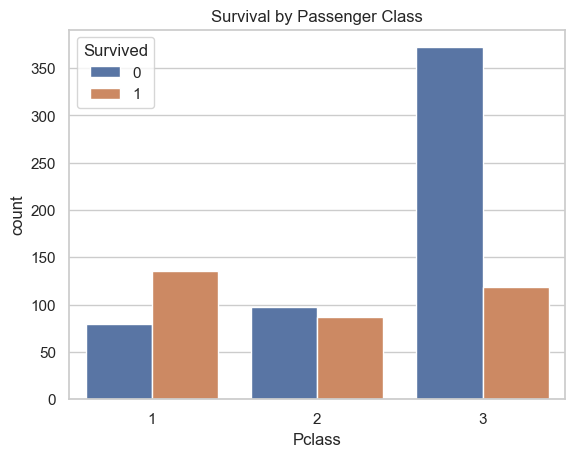

In [11]:
sns.countplot(
    data=train,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.show()

Calculate survival percentages

In [12]:
train.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Analyze age distribution

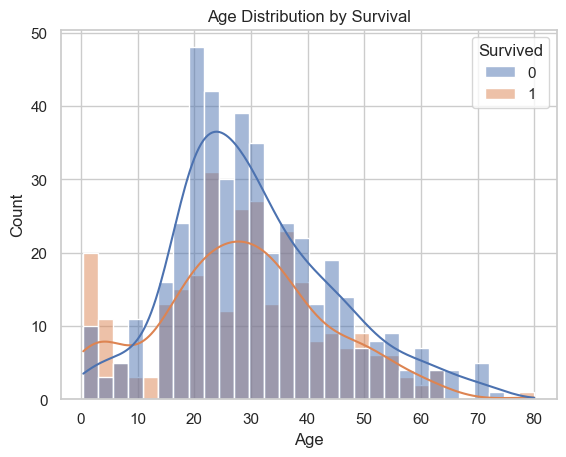

In [14]:
sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Survival")
plt.show()

Analyze family relationships
SibSp = siblings/spouse
Parch = parents/children

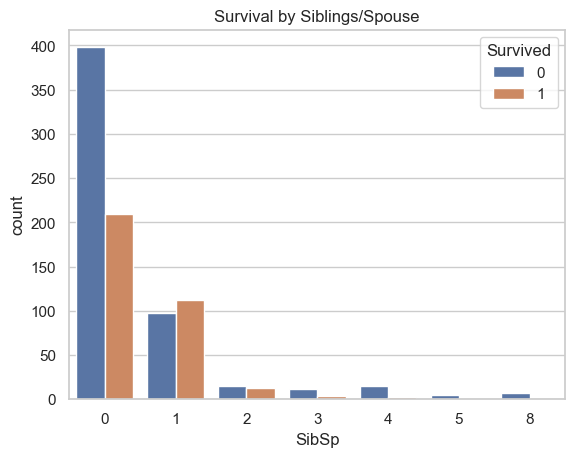

In [16]:
sns.countplot(
    data=train,
    x="SibSp",
    hue="Survived"
)

plt.title("Survival by Siblings/Spouse")
plt.show()

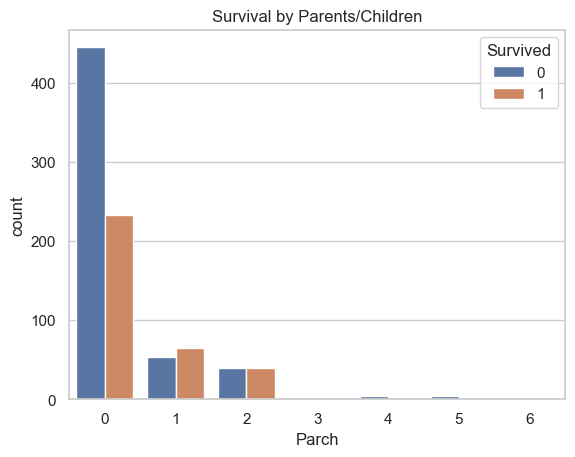

In [17]:
sns.countplot(
    data=train,
    x="Parch",
    hue="Survived"
)

plt.title("Survival by Parents/Children")
plt.show()

Analyze Fare

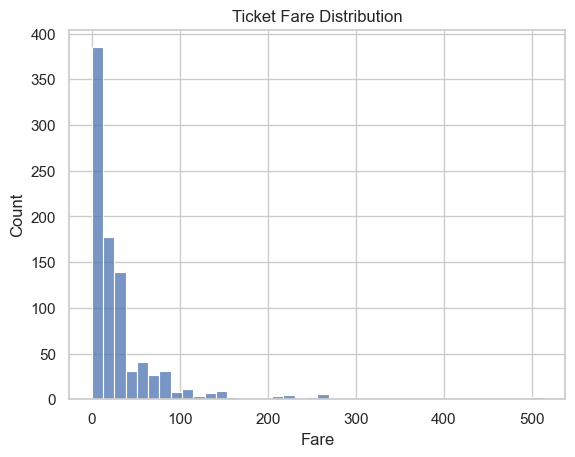

In [20]:
sns.histplot(
    data=train,
    x="Fare",
    bins=40
)

plt.title("Ticket Fare Distribution")
plt.show()

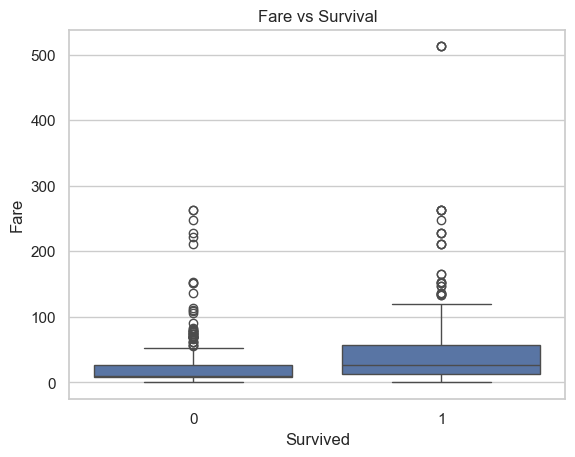

In [21]:
sns.boxplot(
    data=train,
    x="Survived",
    y="Fare"
)

plt.title("Fare vs Survival")
plt.show()

Analyze embarkation port

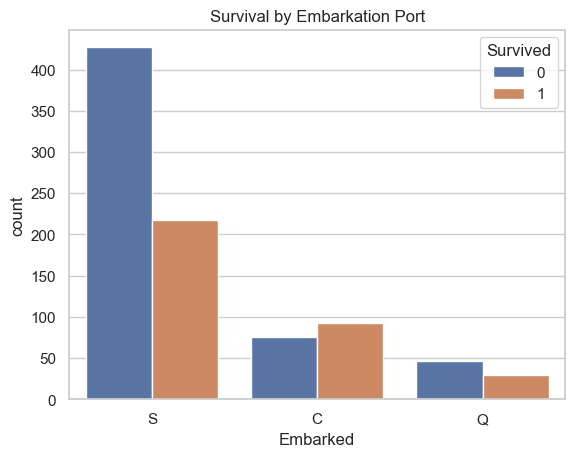

In [22]:
sns.countplot(
    data=train,
    x="Embarked",
    hue="Survived"
)

plt.title("Survival by Embarkation Port")
plt.show()

Correlation view

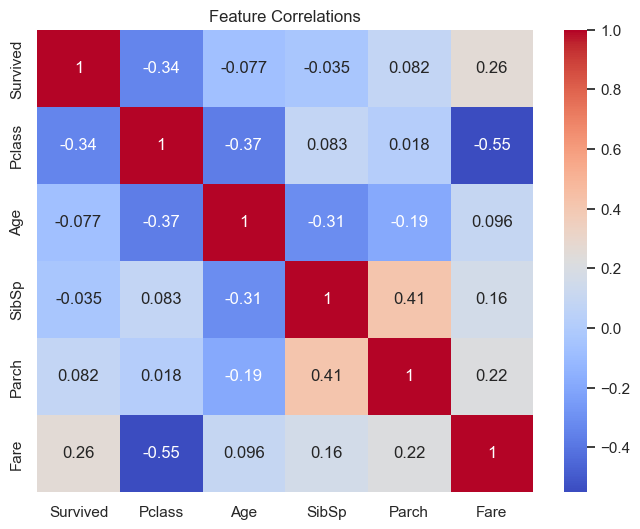

In [23]:
numeric_cols = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    train[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlations")
plt.show()